# Download and Setup PySpark

In [1]:
!pip install pyspark



In [2]:
!ls

# Create a PySpark session directly
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark

sample_data
sample_data


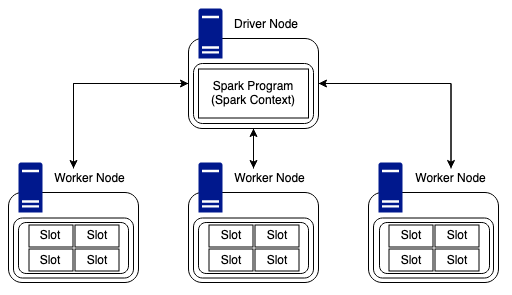

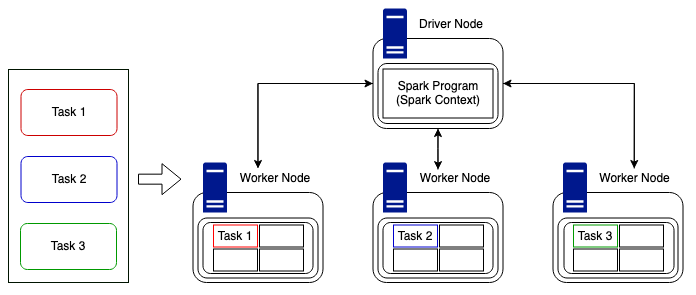

## 1. Reading Data

In [3]:
# Downloading and preprocessing Cars Data downloaded origianlly from https://perso.telecom-paristech.fr/eagan/class/igr204/datasets
# Many of these datasets have been cleaned up by Petra Isenberg, Pierre Dragicevic and Yvonne Jansen
!wget https://jacobceles.github.io/knowledge_repo/colab_and_pyspark/cars.csv

--2026-07-03 10:54:24--  https://jacobceles.github.io/knowledge_repo/colab_and_pyspark/cars.csv
Resolving jacobceles.github.io (jacobceles.github.io)... 185.199.109.153, 185.199.108.153, 185.199.110.153, ...
Connecting to jacobceles.github.io (jacobceles.github.io)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://jacobcelestine.com/knowledge_repo/colab_and_pyspark/cars.csv [following]
--2026-07-03 10:54:24--  https://jacobcelestine.com/knowledge_repo/colab_and_pyspark/cars.csv
Resolving jacobcelestine.com (jacobcelestine.com)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to jacobcelestine.com (jacobcelestine.com)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22608 (22K) [text/csv]
Saving to: ‘cars.csv’

cars.csv            100%[===================>]  22.08K  --.-KB/s    in 0.002s  

2026-07-03 10:54:24 (9.93 MB/s) - ‘cars.csv’ saved [22608/22608]



In [4]:
# Load data from csv to a dataframe.
# header=True means the first row is a header
# sep=';' means the column are seperated using ''
df = spark.read.csv('cars.csv', header=True, sep=";", inferSchema=True) # inferSchema =True
df.show(5)

+--------------------+----+---------+------------+----------+------+------------+-----+------+
|                 Car| MPG|Cylinders|Displacement|Horsepower|Weight|Acceleration|Model|Origin|
+--------------------+----+---------+------------+----------+------+------------+-----+------+
|Chevrolet Chevell...|18.0|        8|       307.0|     130.0|  3504|        12.0|   70|    US|
|   Buick Skylark 320|15.0|        8|       350.0|     165.0|  3693|        11.5|   70|    US|
|  Plymouth Satellite|18.0|        8|       318.0|     150.0|  3436|        11.0|   70|    US|
|       AMC Rebel SST|16.0|        8|       304.0|     150.0|  3433|        12.0|   70|    US|
|         Ford Torino|17.0|        8|       302.0|     140.0|  3449|        10.5|   70|    US|
+--------------------+----+---------+------------+----------+------+------------+-----+------+
only showing top 5 rows


##  2. Viewing the data

In [5]:
#df.show() is the most commonly used method to view a dataframe. There are a few parameters we can pass to this method, like the number of rows and truncaiton.
# For example, df.show(5, False) or df.show(5, truncate=False) will show the entire data wihtout any truncation.
df.show(5,truncate=False)

+-------------------------+----+---------+------------+----------+------+------------+-----+------+
|Car                      |MPG |Cylinders|Displacement|Horsepower|Weight|Acceleration|Model|Origin|
+-------------------------+----+---------+------------+----------+------+------------+-----+------+
|Chevrolet Chevelle Malibu|18.0|8        |307.0       |130.0     |3504  |12.0        |70   |US    |
|Buick Skylark 320        |15.0|8        |350.0       |165.0     |3693  |11.5        |70   |US    |
|Plymouth Satellite       |18.0|8        |318.0       |150.0     |3436  |11.0        |70   |US    |
|AMC Rebel SST            |16.0|8        |304.0       |150.0     |3433  |12.0        |70   |US    |
|Ford Torino              |17.0|8        |302.0       |140.0     |3449  |10.5        |70   |US    |
+-------------------------+----+---------+------------+----------+------+------------+-----+------+
only showing top 5 rows


In [6]:
# Create a new DataFrame by taking the first n rows
x =df.limit(2)
x.show()

+--------------------+----+---------+------------+----------+------+------------+-----+------+
|                 Car| MPG|Cylinders|Displacement|Horsepower|Weight|Acceleration|Model|Origin|
+--------------------+----+---------+------------+----------+------+------------+-----+------+
|Chevrolet Chevell...|18.0|        8|       307.0|     130.0|  3504|        12.0|   70|    US|
|   Buick Skylark 320|15.0|        8|       350.0|     165.0|  3693|        11.5|   70|    US|
+--------------------+----+---------+------------+----------+------+------------+-----+------+



In [7]:
# will return a list of n Row objects.
r5 = df.take(5)

In [8]:
r5[0]

Row(Car='Chevrolet Chevelle Malibu', MPG=18.0, Cylinders=8, Displacement=307.0, Horsepower=130.0, Weight=Decimal('3504'), Acceleration=12.0, Model=70, Origin='US')

In [9]:
# Data Types of Spark Dataframe
df.printSchema() # or df.dtypes

root
 |-- Car: string (nullable = true)
 |-- MPG: double (nullable = true)
 |-- Cylinders: integer (nullable = true)
 |-- Displacement: double (nullable = true)
 |-- Horsepower: double (nullable = true)
 |-- Weight: decimal(4,0) (nullable = true)
 |-- Acceleration: double (nullable = true)
 |-- Model: integer (nullable = true)
 |-- Origin: string (nullable = true)



## 3. Summary Statistics

In [10]:
#Summary stats
df.describe().show()

+-------+--------------------+------------------+-----------------+------------------+-----------------+-----------------+------------------+------------------+------+
|summary|                 Car|               MPG|        Cylinders|      Displacement|       Horsepower|           Weight|      Acceleration|             Model|Origin|
+-------+--------------------+------------------+-----------------+------------------+-----------------+-----------------+------------------+------------------+------+
|  count|                 406|               406|              406|               406|              406|              406|               406|               406|   406|
|   mean|                NULL|23.051231527093602|5.475369458128079| 194.7795566502463|103.5295566502463|        2979.4138|15.519704433497521| 75.92118226600985|  NULL|
| stddev|                NULL|   8.4017773522706|1.712159631548529|104.92245837948867|40.52065912106347|847.0043282393513|2.8033588163425462|3.7487373454558743|

## 4. Spark DataFrame Operations

4.1 Selecting Columns

In [11]:
print(df.Car)
df.select(df.Car).show(truncate=False)

Column<'Car'>
+--------------------------------+
|Car                             |
+--------------------------------+
|Chevrolet Chevelle Malibu       |
|Buick Skylark 320               |
|Plymouth Satellite              |
|AMC Rebel SST                   |
|Ford Torino                     |
|Ford Galaxie 500                |
|Chevrolet Impala                |
|Plymouth Fury iii               |
|Pontiac Catalina                |
|AMC Ambassador DPL              |
|Citroen DS-21 Pallas            |
|Chevrolet Chevelle Concours (sw)|
|Ford Torino (sw)                |
|Plymouth Satellite (sw)         |
|AMC Rebel SST (sw)              |
|Dodge Challenger SE             |
|Plymouth 'Cuda 340              |
|Ford Mustang Boss 302           |
|Chevrolet Monte Carlo           |
|Buick Estate Wagon (sw)         |
+--------------------------------+
only showing top 20 rows


4.2 Grouping by columns

In [12]:
# Group By a column in PySpark
df.groupBy('Origin').count().show(5)

+------+-----+
|Origin|count|
+------+-----+
|Europe|   73|
|    US|  254|
| Japan|   79|
+------+-----+



4.3 Sorting Rows

In [13]:
# Sort Rows in PySpark
# By default the data will be sorted in ascending order
df.orderBy('Cylinders').show(truncate=False)

+----------------------------+----+---------+------------+----------+------+------------+-----+------+
|Car                         |MPG |Cylinders|Displacement|Horsepower|Weight|Acceleration|Model|Origin|
+----------------------------+----+---------+------------+----------+------+------------+-----+------+
|Mazda RX2 Coupe             |19.0|3        |70.0        |97.0      |2330  |13.5        |72   |Japan |
|Mazda RX3                   |18.0|3        |70.0        |90.0      |2124  |13.5        |73   |Japan |
|Mazda RX-4                  |21.5|3        |80.0        |110.0     |2720  |13.5        |77   |Japan |
|Mazda RX-7 GS               |23.7|3        |70.0        |100.0     |2420  |12.5        |80   |Japan |
|Datsun 510 (sw)             |28.0|4        |97.0        |92.0      |2288  |17.0        |72   |Japan |
|Mercury Capri 2000          |23.0|4        |122.0       |86.0      |2220  |14.0        |71   |US    |
|Chevrolet Vega (sw)         |22.0|4        |140.0       |72.0      |2408

## 5. Spark SQL
Spark SQL is a Spark module for structured data processing

*No of Cars with 3 cylinders ?*

In [14]:
# Register the DataFrame as a temporary SQL table
df.createOrReplaceTempView("cars")

# Execute SQL query to count the number of cars with 3 cylinders
result = spark.sql("SELECT COUNT(*) AS count FROM cars WHERE Cylinders = 3")
result.show()


+-----+
|count|
+-----+
|    4|
+-----+



In [15]:
spark.sql("SELECT * FROM cars").show()

+--------------------+----+---------+------------+----------+------+------------+-----+------+
|                 Car| MPG|Cylinders|Displacement|Horsepower|Weight|Acceleration|Model|Origin|
+--------------------+----+---------+------------+----------+------+------------+-----+------+
|Chevrolet Chevell...|18.0|        8|       307.0|     130.0|  3504|        12.0|   70|    US|
|   Buick Skylark 320|15.0|        8|       350.0|     165.0|  3693|        11.5|   70|    US|
|  Plymouth Satellite|18.0|        8|       318.0|     150.0|  3436|        11.0|   70|    US|
|       AMC Rebel SST|16.0|        8|       304.0|     150.0|  3433|        12.0|   70|    US|
|         Ford Torino|17.0|        8|       302.0|     140.0|  3449|        10.5|   70|    US|
|    Ford Galaxie 500|15.0|        8|       429.0|     198.0|  4341|        10.0|   70|    US|
|    Chevrolet Impala|14.0|        8|       454.0|     220.0|  4354|         9.0|   70|    US|
|   Plymouth Fury iii|14.0|        8|       440.0|

## 6. RDD - Resilient Distributed Dataset
 It is a fault-tolerant, immutable, distributed collection of objects. Immutable means that once you create an RDD, you cannot change it. The data within RDDs is segmented into logical partitions, allowing for distributed computation across multiple nodes within the cluster.

 **Key Features**

1. Resilient: RDDs are fault-tolerant. They can recover from failures automatically because each RDD maintains the information needed to reconstruct lost data. This is done through a process known as lineage, which tracks all transformations that have been applied to an RDD.

2. Distributed: RDDs are partitioned across multiple nodes in a cluster. This enables distributed processing, where each node operates on a subset of the data, leading to parallelization and faster computation.

3. Dataset: RDDs hold datasets that can be operated on. These datasets can be created from external sources such as Hadoop, HDFS, or local storage, or they can be generated programmatically.



 Source: https://medium.com/@vigneshbw2002/what-is-rdd-in-pyspark-10e7822dfee3


In [16]:
# For example lets say I have a million points
x = [i for i in range(1000000)]
len(x) # Million Numbers in this list

1000000

In [17]:
# Pyspark allows partitioning and storing this

# To store this as RDD
rdd_x = spark.sparkContext.parallelize([int(i) for i in x])

In [18]:
rdd_x # So spark distributing data across machines

ParallelCollectionRDD[59] at readRDDFromFile at PythonRDD.scala:297

**Check what was stored as RDD**

In [19]:
rdd_x.take(20) # This gives you top 20 values/objects stored [ using .collect() can cause the kernel to die as it gets data from all partitions ]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

One drawback of RDD is its immutable : Data cannot be changed (Instead we can create new RDD or apply a function on a RDD)

In [20]:
# We can map  these to lets say their squares
sqr_rdd_x = rdd_x.map(lambda x : (x, x**2)).take(20)
sqr_rdd_x

[(0, 0),
 (1, 1),
 (2, 4),
 (3, 9),
 (4, 16),
 (5, 25),
 (6, 36),
 (7, 49),
 (8, 64),
 (9, 81),
 (10, 100),
 (11, 121),
 (12, 144),
 (13, 169),
 (14, 196),
 (15, 225),
 (16, 256),
 (17, 289),
 (18, 324),
 (19, 361)]

## 7. Analyzing them on graphs

In [32]:
import networkx as nx
import matplotlib.pyplot as plt
# Convert Spark DataFrame to Pandas DataFrame
pandas_df = df.toPandas()

subset_pandas_df = pandas_df.head(15)  # Adjust the number of cars as needed

In [33]:
# Create a NetworkX graph
G = nx.Graph()

# Add nodes
for _, row in subset_pandas_df.iterrows():
    G.add_node(row['Car'], **row.to_dict())

In [34]:
# Add edges based on similarity (e.g., horsepower difference less than a threshold)
threshold = 20
for i, row1 in subset_pandas_df.iterrows():
    for j, row2 in subset_pandas_df.iterrows():
        if i < j:
            if abs(row1['Horsepower'] - row2['Horsepower']) <= threshold:
                G.add_edge(row1['Car'], row2['Car'], weight=abs(row1['Horsepower'] - row2['Horsepower']))

In [35]:
# Check the created graph
print("Nodes:", G.nodes(data=True))
print("Edges:", G.edges(data=True))

Nodes: [('Chevrolet Chevelle Malibu', {'Car': 'Chevrolet Chevelle Malibu', 'MPG': 18.0, 'Cylinders': 8, 'Displacement': 307.0, 'Horsepower': 130.0, 'Weight': Decimal('3504'), 'Acceleration': 12.0, 'Model': 70, 'Origin': 'US'}), ('Buick Skylark 320', {'Car': 'Buick Skylark 320', 'MPG': 15.0, 'Cylinders': 8, 'Displacement': 350.0, 'Horsepower': 165.0, 'Weight': Decimal('3693'), 'Acceleration': 11.5, 'Model': 70, 'Origin': 'US'}), ('Plymouth Satellite', {'Car': 'Plymouth Satellite', 'MPG': 18.0, 'Cylinders': 8, 'Displacement': 318.0, 'Horsepower': 150.0, 'Weight': Decimal('3436'), 'Acceleration': 11.0, 'Model': 70, 'Origin': 'US'}), ('AMC Rebel SST', {'Car': 'AMC Rebel SST', 'MPG': 16.0, 'Cylinders': 8, 'Displacement': 304.0, 'Horsepower': 150.0, 'Weight': Decimal('3433'), 'Acceleration': 12.0, 'Model': 70, 'Origin': 'US'}), ('Ford Torino', {'Car': 'Ford Torino', 'MPG': 17.0, 'Cylinders': 8, 'Displacement': 302.0, 'Horsepower': 140.0, 'Weight': Decimal('3449'), 'Acceleration': 10.5, 'Mode

Shortest path between AMC Rebel SST and Ford Galaxie 500: ['AMC Rebel SST', 'Buick Skylark 320', 'Plymouth Satellite (sw)', 'AMC Ambassador DPL', 'Ford Galaxie 500']


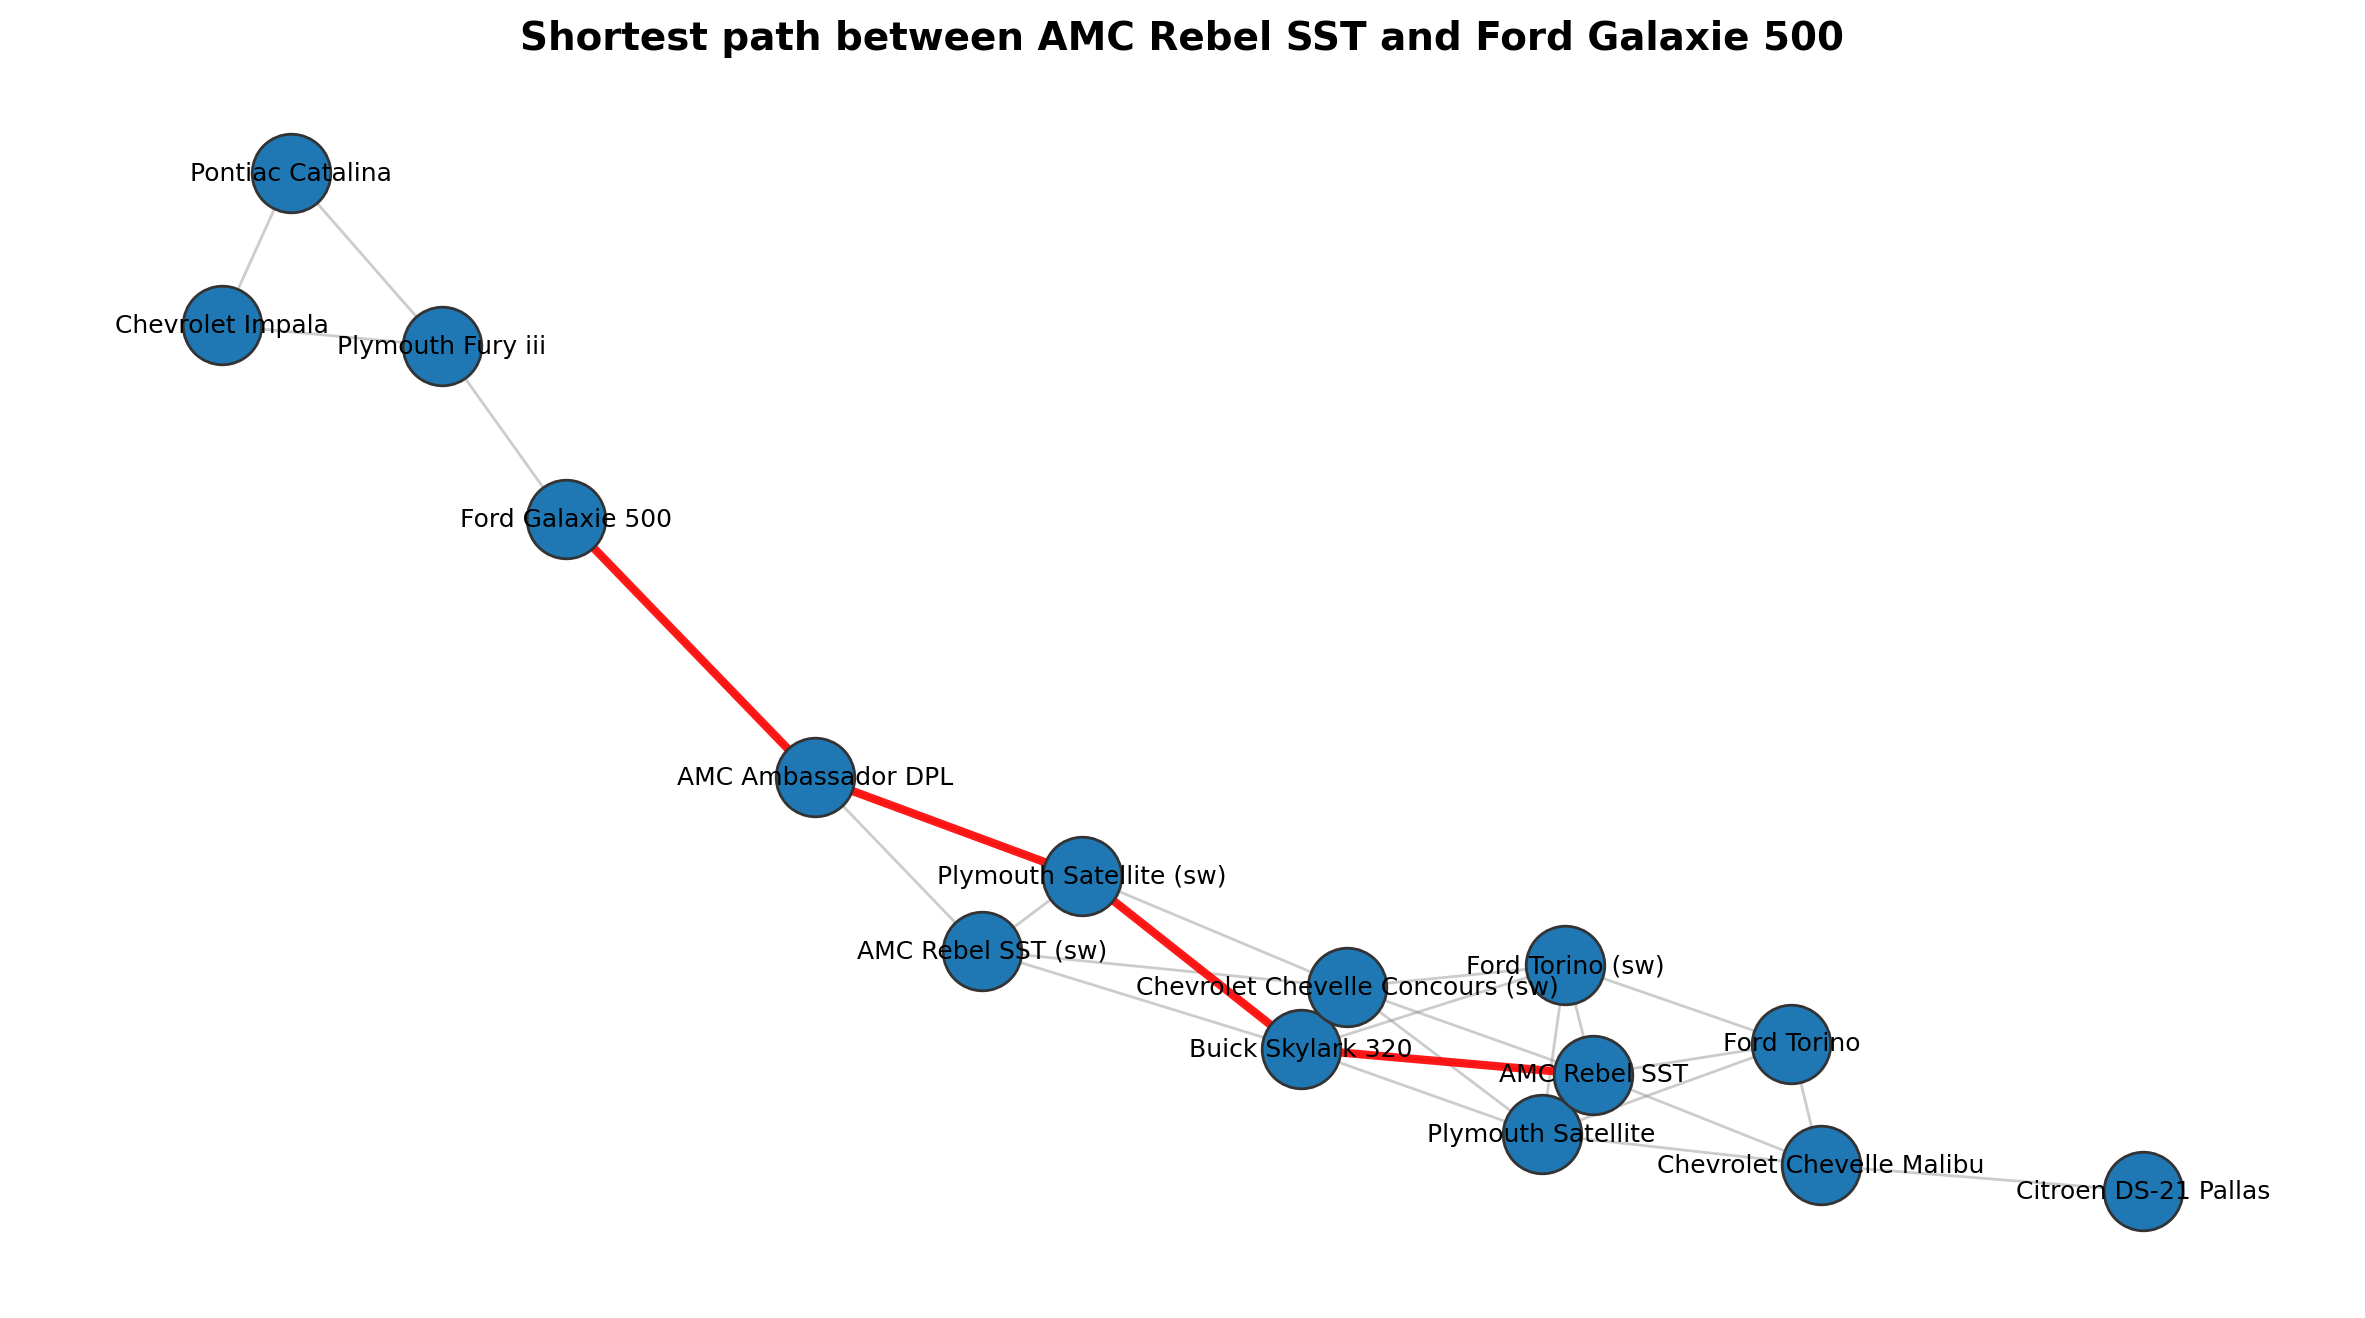

In [42]:
# Calculate the shortest path between two nodes
car1 = "AMC Rebel SST"
car2 = "Ford Galaxie 500"

shortest_path = nx.shortest_path(G, source=car1, target=car2, weight='weight')
print(f"Shortest path between {car1} and {car2}: {shortest_path}")

plt.figure(figsize=(15, 8), dpi=200)

# --- SPREAD OUT NODES BY ADJUSTING K (Optimal distance between nodes) ---
pos = nx.spring_layout(G, k=0.9, iterations=50)

# Visualize the graph and the shortest path
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='#1f77b4', edgecolors='#333')
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=1.0, alpha=0.4, edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=list(zip(shortest_path, shortest_path[1:])), width=3, alpha=0.9, edge_color='r')
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif')

plt.title(f"Shortest path between {car1} and {car2}", fontsize=14, fontweight='bold')
plt.axis('off') # Clean up layout by removing the outer box axis
plt.show()